# PeMS Horizon-Dependent Cross-Channel Dependency Drift v2

This section implements the dependency-drift protocol described in the paper. All source selection and normalization use only the designated training interval.


In [1]:

from pathlib import Path
import gc
import math
import time

import numpy as np
import pandas as pd

import torch
import matplotlib.pyplot as plt

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    free_b, total_b = torch.cuda.mem_get_info()
    print(
        f"CUDA free: {free_b/1024**3:.2f} GiB / "
        f"{total_b/1024**3:.2f} GiB"
    )


PyTorch: 2.4.1+cu121
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
CUDA free: 78.21 GiB / 79.15 GiB


## 1. Configuration

In [2]:

DATA_ROOT = Path("/data/dataset")

DATASETS = {
    "PeMS03": DATA_ROOT / "PeMS03.npz",
    "PeMS04": DATA_ROOT / "PeMS04.npz",
    "PeMS07": DATA_ROOT / "PeMS07.npz",
    "PeMS08": DATA_ROOT / "PeMS08.npz",
}

FEATURE_IDX = 0
TRAIN_RATIO = 0.60

PRED_LENS = [12, 24, 48]

TOP_K_VALUES = [10, 20]

# PeMS: 5-minute interval -> 288 samples/day.
# Alternating daily blocks are used for split-half stability.
STABILITY_BLOCK_LEN = 288

OUTPUT_DIR = Path(
    "./results_pems_horizon_dependency_drift"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# Do not save full C x C matrices unless needed.
SAVE_CORR_MATRICES = False

print("DEVICE:", DEVICE)
print("OUTPUT_DIR:", OUTPUT_DIR)


DEVICE: cuda
OUTPUT_DIR: results_pems_horizon_dependency_drift


In [3]:

def anchors_for_pred_len(H):
    """
    Relative forecast positions:
        1, 25%, 50%, 100%

    H=12 -> [1,3,6,12]
    H=24 -> [1,6,12,24]
    H=48 -> [1,12,24,48]
    """
    anchors = [
        1,
        max(1, int(round(0.25 * H))),
        max(1, int(round(0.50 * H))),
        H,
    ]

    return sorted(set(anchors))


ALL_HORIZONS = sorted(
    set(
        h
        for H in PRED_LENS
        for h in anchors_for_pred_len(H)
    )
)

print("Prediction-length anchors:")
for H in PRED_LENS:
    print(
        f"H={H}:",
        anchors_for_pred_len(H)
    )

print("Unique horizons to compute:", ALL_HORIZONS)


Prediction-length anchors:
H=12: [1, 3, 6, 12]
H=24: [1, 6, 12, 24]
H=48: [1, 12, 24, 48]
Unique horizons to compute: [1, 3, 6, 12, 24, 48]


## 2. Load PeMS training data

In [4]:

def load_train_data(dataset_name):

    path = DATASETS[dataset_name]

    if not path.exists():
        raise FileNotFoundError(path)

    npz = np.load(path)

    if "data" not in npz.files:
        raise KeyError(
            f"{dataset_name}: 'data' not found. "
            f"keys={npz.files}"
        )

    raw = npz["data"]

    if raw.ndim == 3:
        x = raw[:, :, FEATURE_IDX]
    elif raw.ndim == 2:
        x = raw
    else:
        raise ValueError(
            f"Unexpected shape: {raw.shape}"
        )

    x = np.asarray(
        x,
        dtype=np.float32
    )

    if np.isnan(x).any():
        raise ValueError(
            f"{dataset_name}: NaN detected."
        )

    T, C = x.shape

    train_end = int(
        T * TRAIN_RATIO
    )

    train = x[:train_end]

    print(
        f"{dataset_name}: "
        f"T={T:,}, C={C:,}, "
        f"train={train.shape}"
    )

    return train



## 3. Cross-lag correlation

For each source channel \(j\) and target channel \(i\):

\[
r_{ij}^{(h)}
=
\operatorname{Corr}
\left(
x_j(t),
x_i(t+h)
\right)
\]

The returned matrix has shape:

\[
[\text{target},\text{source}]
\]

Only training data are used.


In [5]:

@torch.no_grad()
def cross_lag_corr(
    train_np,
    horizon,
    subset="full",
    block_len=STABILITY_BLOCK_LEN
):
    """
    subset:
        "full"
        "A"  alternating blocks
        "B"  alternating blocks
    """

    T, C = train_np.shape

    n_aligned = T - horizon

    if n_aligned <= 10:
        raise ValueError(
            f"Too few aligned samples for h={horizon}"
        )

    source_t = np.arange(
        n_aligned,
        dtype=np.int64
    )

    if subset == "full":
        idx = source_t

    else:
        block_id = (
            source_t
            // block_len
        )

        if subset == "A":
            mask = (
                block_id % 2
                == 0
            )
        elif subset == "B":
            mask = (
                block_id % 2
                == 1
            )
        else:
            raise ValueError(
                subset
            )

        idx = source_t[mask]

    X_np = train_np[
        idx
    ]

    Y_np = train_np[
        idx + horizon
    ]

    X = torch.as_tensor(
        X_np,
        device=DEVICE,
        dtype=torch.float32
    )

    Y = torch.as_tensor(
        Y_np,
        device=DEVICE,
        dtype=torch.float32
    )

    # Per-channel standardization on the aligned sample set.
    X = (
        X
        - X.mean(
            dim=0,
            keepdim=True
        )
    )

    Y = (
        Y
        - Y.mean(
            dim=0,
            keepdim=True
        )
    )

    X_std = X.std(
        dim=0,
        unbiased=False,
        keepdim=True
    ).clamp_min(
        1e-6
    )

    Y_std = Y.std(
        dim=0,
        unbiased=False,
        keepdim=True
    ).clamp_min(
        1e-6
    )

    X = X / X_std
    Y = Y / Y_std

    n = X.shape[0]

    # source x target
    corr_source_target = (
        X.transpose(0, 1)
        @ Y
    ) / float(n)

    # target x source
    corr = (
        corr_source_target
        .transpose(0, 1)
        .contiguous()
        .clamp(
            -1.0,
            1.0
        )
    )

    del (
        X,
        Y,
        corr_source_target
    )

    return corr


## 4. Dependency-score helpers

In [6]:

def abs_dependency_score(
    corr
):
    """
    |correlation| with self-channel excluded.
    """
    score = corr.abs().clone()

    C = score.shape[0]

    diag = torch.arange(
        C,
        device=score.device
    )

    score[
        diag,
        diag
    ] = float("-inf")

    return score


@torch.no_grad()
def topk_indices(
    score,
    k
):
    C = score.shape[1]

    k = min(
        k,
        C - 1
    )

    return torch.topk(
        score,
        k=k,
        dim=1,
        sorted=True
    ).indices


## 5. Top-K Jaccard

In [7]:

@torch.no_grad()
def jaccard_per_target(
    idx_a,
    idx_b
):
    """
    idx_a, idx_b: [C, K]
    """

    if idx_a.shape != idx_b.shape:
        raise ValueError(
            "Top-K shapes must match."
        )

    K = idx_a.shape[1]

    matches = (
        idx_a.unsqueeze(2)
        ==
        idx_b.unsqueeze(1)
    )

    intersection = (
        matches.any(dim=2)
        .sum(dim=1)
        .float()
    )

    union = (
        2.0 * K
        - intersection
    )

    return (
        intersection
        / union.clamp_min(1.0)
    )


## 6. Full-ranking Spearman correlation

In [8]:

@torch.no_grad()
def rank_matrix(
    score
):
    """
    Returns source-channel ranks for every target.
    Self channel is placed last and later masked out.
    """

    order = torch.argsort(
        score,
        dim=1,
        descending=True
    )

    C = score.shape[1]

    ranks = torch.empty_like(
        order,
        dtype=torch.float32
    )

    rank_values = (
        torch.arange(
            C,
            device=score.device,
            dtype=torch.float32
        )
        .view(
            1,
            C
        )
        .expand(
            C,
            -1
        )
    )

    ranks.scatter_(
        1,
        order,
        rank_values
    )

    return ranks


@torch.no_grad()
def spearman_per_target(
    score_a,
    score_b
):
    """
    Vectorized Spearman correlation over source-channel rankings.
    Self-channel is excluded.
    """

    ra = rank_matrix(
        score_a
    )

    rb = rank_matrix(
        score_b
    )

    C = ra.shape[0]

    mask = ~torch.eye(
        C,
        dtype=torch.bool,
        device=ra.device
    )

    mask_f = mask.float()

    n = float(C - 1)

    mean_a = (
        (ra * mask_f)
        .sum(dim=1)
        / n
    )

    mean_b = (
        (rb * mask_f)
        .sum(dim=1)
        / n
    )

    ca = (
        ra
        - mean_a[:, None]
    ) * mask_f

    cb = (
        rb
        - mean_b[:, None]
    ) * mask_f

    numerator = (
        ca * cb
    ).sum(dim=1)

    denominator = torch.sqrt(
        ca.square()
        .sum(dim=1)
        *
        cb.square()
        .sum(dim=1)
    ).clamp_min(
        1e-12
    )

    return (
        numerator
        / denominator
    )


## Pre-flight test: ranking / Jaccard utilities

This section implements the dependency-drift protocol described in the paper. All source selection and normalization use only the designated training interval.


In [9]:

# Small runtime test before the expensive full-dataset analysis.

toy_a = torch.tensor(
    [
        [float("-inf"), 0.8, 0.5, 0.2],
        [0.7, float("-inf"), 0.4, 0.1],
        [0.6, 0.3, float("-inf"), 0.2],
        [0.5, 0.4, 0.3, float("-inf")],
    ],
    dtype=torch.float32,
    device=DEVICE
)

toy_b = torch.tensor(
    [
        [float("-inf"), 0.7, 0.6, 0.1],
        [0.6, float("-inf"), 0.5, 0.2],
        [0.5, 0.4, float("-inf"), 0.1],
        [0.4, 0.5, 0.2, float("-inf")],
    ],
    dtype=torch.float32,
    device=DEVICE
)

toy_rank = rank_matrix(toy_a)

assert toy_rank.shape == toy_a.shape
assert torch.isfinite(toy_rank).all()

toy_rho = spearman_per_target(
    toy_a,
    toy_b
)

assert toy_rho.shape == (4,)
assert torch.isfinite(toy_rho).all()
assert ((toy_rho >= -1.0001) & (toy_rho <= 1.0001)).all()

toy_idx_a = topk_indices(
    toy_a,
    k=2
)

toy_idx_b = topk_indices(
    toy_b,
    k=2
)

toy_jaccard = jaccard_per_target(
    toy_idx_a,
    toy_idx_b
)

assert toy_jaccard.shape == (4,)
assert ((toy_jaccard >= 0.0) & (toy_jaccard <= 1.0)).all()

print("Pre-flight rank_matrix: OK")
print("Pre-flight Spearman:    OK")
print("Pre-flight Jaccard:     OK")
print("Toy Spearman:", toy_rho.detach().cpu().numpy())
print("Toy Jaccard:", toy_jaccard.detach().cpu().numpy())

del (
    toy_a,
    toy_b,
    toy_rank,
    toy_rho,
    toy_idx_a,
    toy_idx_b,
    toy_jaccard
)

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()


Pre-flight rank_matrix: OK
Pre-flight Spearman:    OK
Pre-flight Jaccard:     OK
Toy Spearman: [1.  1.  1.  0.5]
Toy Jaccard: [1. 1. 1. 1.]


## 7. Signal-strength diagnostics

In [10]:

@torch.no_grad()
def offdiag_mean_abs_corr(
    corr
):
    C = corr.shape[0]

    mask = ~torch.eye(
        C,
        dtype=torch.bool,
        device=corr.device
    )

    return (
        corr.abs()[mask]
        .mean()
        .item()
    )


@torch.no_grad()
def mean_topk_score(
    score,
    k=20
):
    k = min(
        k,
        score.shape[1] - 1
    )

    values = torch.topk(
        score,
        k=k,
        dim=1
    ).values

    return values.mean().item()


## 8. Compute dependency matrices and same-horizon stability

This section implements the dependency-drift protocol described in the paper. All source selection and normalization use only the designated training interval.


In [11]:

horizon_rows = []
pair_rows = []
summary_rows = []

for dataset_name in DATASETS.keys():

    print(
        "\n"
        + "#"
        * 100
    )
    print(dataset_name)
    print("#" * 100)

    train = load_train_data(
        dataset_name
    )

    T_train, C = train.shape

    corr_full = {}
    corr_A = {}
    corr_B = {}

    score_full = {}
    score_A = {}
    score_B = {}

    stability = {}

    t_dataset = time.time()

    # -------------------------------------------------
    # Horizon-wise dependency estimates
    # -------------------------------------------------
    for h in ALL_HORIZONS:

        print(
            f"\n{dataset_name} | h={h}"
        )

        t0 = time.time()

        corr_full[h] = cross_lag_corr(
            train,
            h,
            subset="full"
        )

        corr_A[h] = cross_lag_corr(
            train,
            h,
            subset="A"
        )

        corr_B[h] = cross_lag_corr(
            train,
            h,
            subset="B"
        )

        score_full[h] = (
            abs_dependency_score(
                corr_full[h]
            )
        )

        score_A[h] = (
            abs_dependency_score(
                corr_A[h]
            )
        )

        score_B[h] = (
            abs_dependency_score(
                corr_B[h]
            )
        )

        row = {
            "dataset":
                dataset_name,
            "horizon":
                h,
            "channels":
                C,
            "train_length":
                T_train,
            "mean_abs_corr":
                offdiag_mean_abs_corr(
                    corr_full[h]
                ),
            "mean_top20_abs_corr":
                mean_topk_score(
                    score_full[h],
                    k=20
                ),
        }

        # Same-horizon split-half stability.
        for K in TOP_K_VALUES:

            idx_A = topk_indices(
                score_A[h],
                K
            )

            idx_B = topk_indices(
                score_B[h],
                K
            )

            jac = jaccard_per_target(
                idx_A,
                idx_B
            )

            row[
                f"stability_jaccard_K{K}_mean"
            ] = jac.mean().item()

            row[
                f"stability_jaccard_K{K}_median"
            ] = jac.median().item()

            del (
                idx_A,
                idx_B,
                jac
            )

        rho_same = spearman_per_target(
            score_A[h],
            score_B[h]
        )

        row[
            "stability_spearman_mean"
        ] = rho_same.mean().item()

        row[
            "stability_spearman_median"
        ] = rho_same.median().item()

        stability[h] = row

        horizon_rows.append(
            row
        )

        print(
            f"  mean |corr|={row['mean_abs_corr']:.4f}"
        )

        print(
            f"  top20 |corr|={row['mean_top20_abs_corr']:.4f}"
        )

        print(
            "  split stability K20="
            f"{row['stability_jaccard_K20_mean']:.4f}"
        )

        print(
            "  split rank rho="
            f"{row['stability_spearman_mean']:.4f}"
        )

        print(
            f"  elapsed={time.time()-t0:.1f}s"
        )

    # -------------------------------------------------
    # Cross-horizon drift for each prediction length
    # -------------------------------------------------
    for H in PRED_LENS:

        anchors = anchors_for_pred_len(
            H
        )

        local_pairs = []

        for ai in range(
            len(anchors)
        ):

            for bi in range(
                ai + 1,
                len(anchors)
            ):

                h1 = anchors[ai]
                h2 = anchors[bi]

                pair = {
                    "dataset":
                        dataset_name,
                    "pred_len":
                        H,
                    "h1":
                        h1,
                    "h2":
                        h2,
                    "horizon_gap":
                        h2 - h1,
                    "relative_gap":
                        (h2 - h1)
                        / float(H),
                }

                # -----------------------------
                # Top-K drift
                # -----------------------------
                for K in TOP_K_VALUES:

                    idx1 = topk_indices(
                        score_full[h1],
                        K
                    )

                    idx2 = topk_indices(
                        score_full[h2],
                        K
                    )

                    jac = jaccard_per_target(
                        idx1,
                        idx2
                    )

                    jac_mean = (
                        jac.mean()
                        .item()
                    )

                    cross_drift = (
                        1.0
                        - jac_mean
                    )

                    s1 = (
                        stability[h1][
                            f"stability_jaccard_K{K}_mean"
                        ]
                    )

                    s2 = (
                        stability[h2][
                            f"stability_jaccard_K{K}_mean"
                        ]
                    )

                    instability_baseline = (
                        (
                            1.0 - s1
                        )
                        +
                        (
                            1.0 - s2
                        )
                    ) / 2.0

                    adjusted = (
                        cross_drift
                        - instability_baseline
                    )

                    pair[
                        f"jaccard_K{K}_mean"
                    ] = jac_mean

                    pair[
                        f"drift_jaccard_K{K}"
                    ] = cross_drift

                    pair[
                        f"instability_baseline_K{K}"
                    ] = instability_baseline

                    pair[
                        f"adjusted_drift_jaccard_K{K}"
                    ] = adjusted

                    pair[
                        f"adjusted_drift_jaccard_K{K}_clipped"
                    ] = max(
                        0.0,
                        adjusted
                    )

                    del (
                        idx1,
                        idx2,
                        jac
                    )

                # -----------------------------
                # Full-rank drift
                # -----------------------------
                rho = spearman_per_target(
                    score_full[h1],
                    score_full[h2]
                )

                rho_mean = (
                    rho.mean()
                    .item()
                )

                rank_drift = (
                    1.0
                    - rho_mean
                )

                rank_noise = (
                    (
                        1.0
                        -
                        stability[h1][
                            "stability_spearman_mean"
                        ]
                    )
                    +
                    (
                        1.0
                        -
                        stability[h2][
                            "stability_spearman_mean"
                        ]
                    )
                ) / 2.0

                pair[
                    "spearman_mean"
                ] = rho_mean

                pair[
                    "rank_drift"
                ] = rank_drift

                pair[
                    "rank_instability_baseline"
                ] = rank_noise

                pair[
                    "adjusted_rank_drift"
                ] = (
                    rank_drift
                    - rank_noise
                )

                pair[
                    "adjusted_rank_drift_clipped"
                ] = max(
                    0.0,
                    rank_drift
                    - rank_noise
                )

                pair_rows.append(
                    pair
                )

                local_pairs.append(
                    pair
                )

        local_df = pd.DataFrame(
            local_pairs
        )

        endpoint = local_df[
            (
                local_df.h1 == 1
            )
            &
            (
                local_df.h2 == H
            )
        ].iloc[0]

        summary = {
            "dataset":
                dataset_name,
            "pred_len":
                H,
            "channels":
                C,

            "endpoint_drift_K10":
                endpoint[
                    "drift_jaccard_K10"
                ],
            "endpoint_adjusted_drift_K10":
                endpoint[
                    "adjusted_drift_jaccard_K10"
                ],
            "endpoint_drift_K20":
                endpoint[
                    "drift_jaccard_K20"
                ],
            "endpoint_adjusted_drift_K20":
                endpoint[
                    "adjusted_drift_jaccard_K20"
                ],

            "endpoint_rank_drift":
                endpoint[
                    "rank_drift"
                ],
            "endpoint_adjusted_rank_drift":
                endpoint[
                    "adjusted_rank_drift"
                ],

            "avg_pairwise_drift_K10":
                local_df[
                    "drift_jaccard_K10"
                ].mean(),
            "avg_pairwise_adjusted_drift_K10":
                local_df[
                    "adjusted_drift_jaccard_K10"
                ].mean(),

            "avg_pairwise_drift_K20":
                local_df[
                    "drift_jaccard_K20"
                ].mean(),
            "avg_pairwise_adjusted_drift_K20":
                local_df[
                    "adjusted_drift_jaccard_K20"
                ].mean(),

            "avg_pairwise_rank_drift":
                local_df[
                    "rank_drift"
                ].mean(),
            "avg_pairwise_adjusted_rank_drift":
                local_df[
                    "adjusted_rank_drift"
                ].mean(),

            "corr_signal_h1":
                stability[1][
                    "mean_top20_abs_corr"
                ],
            "corr_signal_hH":
                stability[H][
                    "mean_top20_abs_corr"
                ],
        }

        summary_rows.append(
            summary
        )

    # -------------------------------------------------
    # Optional matrix save
    # -------------------------------------------------
    if SAVE_CORR_MATRICES:

        save_dir = (
            OUTPUT_DIR
            /
            "corr_matrices"
            /
            dataset_name
        )

        save_dir.mkdir(
            parents=True,
            exist_ok=True
        )

        for h in ALL_HORIZONS:

            np.save(
                save_dir
                /
                f"corr_full_h{h}.npy",
                corr_full[h]
                .detach()
                .cpu()
                .numpy()
            )

    print(
        f"\n{dataset_name} total elapsed: "
        f"{time.time()-t_dataset:.1f}s"
    )

    del (
        train,
        corr_full,
        corr_A,
        corr_B,
        score_full,
        score_A,
        score_B,
        stability
    )

    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()



####################################################################################################
PeMS03
####################################################################################################
PeMS03: T=26,208, C=358, train=(15724, 358)

PeMS03 | h=1
  mean |corr|=0.8397
  top20 |corr|=0.9340
  split stability K20=0.6972
  split rank rho=0.9767
  elapsed=0.1s

PeMS03 | h=3
  mean |corr|=0.8341
  top20 |corr|=0.9250
  split stability K20=0.6896
  split rank rho=0.9758
  elapsed=0.0s

PeMS03 | h=6
  mean |corr|=0.8237
  top20 |corr|=0.9126
  split stability K20=0.7095
  split rank rho=0.9755
  elapsed=0.0s

PeMS03 | h=12
  mean |corr|=0.7876
  top20 |corr|=0.8808
  split stability K20=0.6757
  split rank rho=0.9772
  elapsed=0.0s

PeMS03 | h=24
  mean |corr|=0.6566
  top20 |corr|=0.7745
  split stability K20=0.7118
  split rank rho=0.9827
  elapsed=0.0s

PeMS03 | h=48
  mean |corr|=0.3070
  top20 |corr|=0.4585
  split stability K20=0.7879
  split rank rho=0.9841
  elapse

## 9. Horizon-wise stability table

In [12]:

horizon_df = pd.DataFrame(
    horizon_rows
)

display(
    horizon_df.round(
        4
    )
)

horizon_df.to_csv(
    OUTPUT_DIR
    /
    "horizon_stability.csv",
    index=False
)


,dataset,horizon,channels,train_length,mean_abs_corr,mean_top20_abs_corr,stability_jaccard_K10_mean,stability_jaccard_K10_median,stability_jaccard_K20_mean,stability_jaccard_K20_median,stability_spearman_mean,stability_spearman_median
0,PeMS03,1,358,15724,0.8397,0.9340,0.7117,0.6667,0.6972,0.7391,0.9767,0.9808
1,PeMS03,3,358,15724,0.8341,0.9250,0.6766,0.6667,0.6896,0.7391,0.9758,0.9803
2,PeMS03,6,358,15724,0.8237,0.9126,0.6292,0.6667,0.7095,0.7391,0.9755,0.9800
3,PeMS03,12,358,15724,0.7876,0.8808,0.6449,0.6667,0.6757,0.6667,0.9772,0.9821
4,PeMS03,24,358,15724,0.6566,0.7745,0.7272,0.6667,0.7118,0.7391,0.9827,0.9871
5,PeMS03,48,358,15724,0.3070,0.4585,0.6553,0.6667,0.7879,0.8182,0.9841,0.9880
6,PeMS04,1,307,10195,0.7694,0.9100,0.6032,0.6667,0.6228,0.6667,0.9574,0.9630
7,PeMS04,3,307,10195,0.7658,0.9057,0.6050,0.6667,0.6373,0.6667,0.9566,0.9616
8,PeMS04,6,307,10195,0.7577,0.8979,0.5982,0.6667,0.6489,0.6667,0.9567,0.9576
9,PeMS04,12,307,10195,0.7278,0.8732,0.5610,0.5385,0.6144,0.6667,0.9588,0.9605


## 10. Cross-horizon pairwise drift

In [13]:

pair_df = pd.DataFrame(
    pair_rows
)

display(
    pair_df.round(
        4
    )
)

pair_df.to_csv(
    OUTPUT_DIR
    /
    "pairwise_dependency_drift.csv",
    index=False
)


,dataset,pred_len,h1,h2,horizon_gap,relative_gap,jaccard_K10_mean,drift_jaccard_K10,instability_baseline_K10,adjusted_drift_jaccard_K10,...,jaccard_K20_mean,drift_jaccard_K20,instability_baseline_K20,adjusted_drift_jaccard_K20,adjusted_drift_jaccard_K20_clipped,spearman_mean,rank_drift,rank_instability_baseline,adjusted_rank_drift,adjusted_rank_drift_clipped
0,PeMS03,12,1,3,2,0.1667,0.7426,0.2574,0.3058,-0.0484,...,0.7564,0.2436,0.3066,-0.0630,0.0000,0.9903,0.0097,0.0237,-0.0140,0.0000
1,PeMS03,12,1,6,5,0.4167,0.4937,0.5063,0.3295,0.1767,...,0.5287,0.4713,0.2966,0.1747,0.1747,0.9490,0.0510,0.0239,0.0271,0.0271
2,PeMS03,12,1,12,11,0.9167,0.1577,0.8423,0.3217,0.5206,...,0.2149,0.7851,0.3135,0.4716,0.4716,0.7978,0.2022,0.0230,0.1792,0.1792
3,PeMS03,12,3,6,3,0.2500,0.6279,0.3721,0.3471,0.0250,...,0.6725,0.3275,0.3004,0.0271,0.0271,0.9806,0.0194,0.0244,-0.0050,0.0000
4,PeMS03,12,3,12,9,0.7500,0.1988,0.8012,0.3392,0.4620,...,0.2758,0.7242,0.3173,0.4069,0.4069,0.8607,0.1393,0.0235,0.1158,0.1158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,PeMS08,48,1,24,23,0.4792,0.0924,0.9076,0.3759,0.5317,...,0.1361,0.8639,0.3530,0.5109,0.5109,0.5499,0.4501,0.0305,0.4196,0.4196
68,PeMS08,48,1,48,47,0.9792,0.0256,0.9744,0.3161,0.6583,...,0.0564,0.9436,0.3219,0.6217,0.6217,0.0492,0.9508,0.0313,0.9195,0.9195
69,PeMS08,48,12,24,12,0.2500,0.3137,0.6863,0.4266,0.2597,...,0.3993,0.6007,0.3596,0.2411,0.2411,0.8768,0.1232,0.0301,0.0930,0.0930
70,PeMS08,48,12,48,36,0.7500,0.1076,0.8924,0.3668,0.5256,...,0.1648,0.8352,0.3286,0.5066,0.5066,0.4325,0.5675,0.0309,0.5365,0.5365


## 11. Dataset × prediction-length summary

In [14]:

summary_df = pd.DataFrame(
    summary_rows
)

display(
    summary_df.round(
        4
    )
)

summary_df.to_csv(
    OUTPUT_DIR
    /
    "dependency_drift_summary.csv",
    index=False
)


,dataset,pred_len,channels,endpoint_drift_K10,endpoint_adjusted_drift_K10,endpoint_drift_K20,endpoint_adjusted_drift_K20,endpoint_rank_drift,endpoint_adjusted_rank_drift,avg_pairwise_drift_K10,avg_pairwise_adjusted_drift_K10,avg_pairwise_drift_K20,avg_pairwise_adjusted_drift_K20,avg_pairwise_rank_drift,avg_pairwise_adjusted_rank_drift,corr_signal_h1,corr_signal_hH
0,PeMS03,12,358,0.8423,0.5206,0.7851,0.4716,0.2022,0.1792,0.5771,0.2427,0.5237,0.2167,0.0809,0.0572,0.9340,0.8808
1,PeMS03,24,358,0.9587,0.6781,0.9314,0.6359,0.5102,0.4899,0.7606,0.4389,0.7175,0.4161,0.2093,0.1873,0.9340,0.7745
2,PeMS03,48,358,0.9948,0.6782,0.9831,0.7257,0.9135,0.8939,0.8539,0.5386,0.8227,0.5409,0.4014,0.3816,0.9340,0.4585
3,PeMS04,12,307,0.7946,0.3767,0.6985,0.3171,0.1864,0.1445,0.5241,0.1159,0.4511,0.0820,0.0749,0.0323,0.9100,0.8732
4,PeMS04,24,307,0.9496,0.5736,0.9091,0.5522,0.5668,0.5291,0.7343,0.3361,0.6676,0.3049,0.2379,0.1980,0.9100,0.7927
5,PeMS04,48,307,0.9969,0.6506,0.9873,0.6408,1.1545,1.1042,0.8567,0.4850,0.8170,0.4632,0.5422,0.4986,0.9100,0.5385
6,PeMS07,12,883,0.8894,0.4966,0.8570,0.5180,0.1584,0.1339,0.6328,0.2568,0.5860,0.2455,0.0634,0.0384,0.9291,0.8792
7,PeMS07,24,883,0.9703,0.6401,0.9582,0.6608,0.3894,0.3666,0.8116,0.4279,0.7717,0.4464,0.1605,0.1371,0.9291,0.7734
8,PeMS07,48,883,0.9950,0.6115,0.9943,0.6801,0.7726,0.7468,0.9221,0.5178,0.8938,0.5765,0.3604,0.3370,0.9291,0.4484
9,PeMS08,12,170,0.7240,0.2771,0.6520,0.2594,0.1542,0.1219,0.5029,0.0692,0.4520,0.0656,0.0634,0.0310,0.8984,0.8594


## 12. Endpoint drift table

In [15]:

endpoint_table = (
    summary_df
    .pivot(
        index="dataset",
        columns="pred_len",
        values=
            "endpoint_adjusted_drift_K20"
    )
)

print(
    "Noise-adjusted endpoint Top-K drift "
    "(K=20): 1 vs H"
)

display(
    endpoint_table.round(
        4
    )
)


Noise-adjusted endpoint Top-K drift (K=20): 1 vs H


pred_len,12,24,48
dataset,,,
PeMS03,0.4716,0.6359,0.7257
PeMS04,0.3171,0.5522,0.6408
PeMS07,0.5180,0.6608,0.6801
PeMS08,0.2594,0.5109,0.6217


## 13. Average pairwise drift table

In [16]:

avg_table = (
    summary_df
    .pivot(
        index="dataset",
        columns="pred_len",
        values=
            "avg_pairwise_adjusted_drift_K20"
    )
)

print(
    "Noise-adjusted average pairwise "
    "Top-K drift (K=20)"
)

display(
    avg_table.round(
        4
    )
)


Noise-adjusted average pairwise Top-K drift (K=20)


pred_len,12,24,48
dataset,,,
PeMS03,0.2167,0.4161,0.5409
PeMS04,0.0820,0.3049,0.4632
PeMS07,0.2455,0.4464,0.5765
PeMS08,0.0656,0.2528,0.4077


## 14. Does horizon separation increase dependency drift?

,relative_gap,drift_jaccard_K20,adjusted_drift_jaccard_K20,rank_drift,adjusted_rank_drift
0,0.1667,0.2478,-0.1008,0.0092,-0.0223
1,0.2083,0.4580,0.1162,0.0455,0.0143
2,0.2292,0.7482,0.3915,0.1753,0.1449
3,0.2500,0.5150,0.1701,0.0682,0.0385
4,0.4167,0.4580,0.1162,0.0455,0.0143
5,0.4583,0.7482,0.3915,0.1753,0.1449
6,0.4792,0.9157,0.5900,0.4791,0.4513
7,0.5000,0.6387,0.3120,0.1597,0.1311
8,0.7500,0.8102,0.4759,0.3281,0.2983
9,0.9167,0.7482,0.3915,0.1753,0.1449


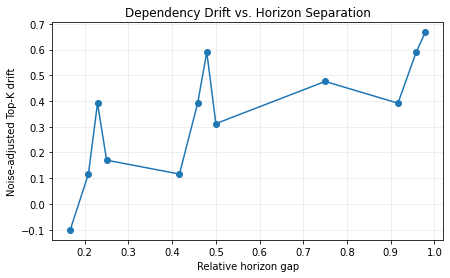

In [17]:

gap_summary = (
    pair_df
    .groupby(
        "relative_gap"
    )
    [
        [
            "drift_jaccard_K20",
            "adjusted_drift_jaccard_K20",
            "rank_drift",
            "adjusted_rank_drift"
        ]
    ]
    .mean()
    .reset_index()
)

display(
    gap_summary.round(
        4
    )
)

plt.figure(
    figsize=(7, 4)
)

plt.plot(
    gap_summary[
        "relative_gap"
    ],
    gap_summary[
        "adjusted_drift_jaccard_K20"
    ],
    marker="o"
)

plt.xlabel(
    "Relative horizon gap"
)

plt.ylabel(
    "Noise-adjusted Top-K drift"
)

plt.title(
    "Dependency Drift vs. Horizon Separation"
)

plt.grid(
    alpha=0.25
)

plt.show()


## 15. Signal weakening vs. ranking instability

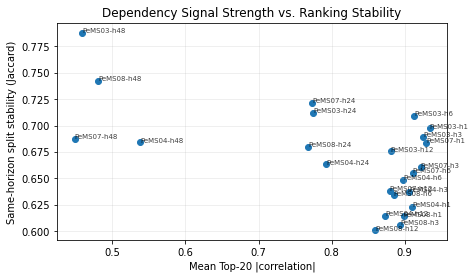

In [18]:

plot_df = horizon_df.copy()

plt.figure(
    figsize=(7, 4)
)

plt.scatter(
    plot_df[
        "mean_top20_abs_corr"
    ],
    plot_df[
        "stability_jaccard_K20_mean"
    ]
)

for _, row in plot_df.iterrows():

    plt.annotate(
        f"{row['dataset']}-h{int(row['horizon'])}",
        (
            row[
                "mean_top20_abs_corr"
            ],
            row[
                "stability_jaccard_K20_mean"
            ]
        ),
        fontsize=7,
        alpha=0.75
    )

plt.xlabel(
    "Mean Top-20 |correlation|"
)

plt.ylabel(
    "Same-horizon split stability (Jaccard)"
)

plt.title(
    "Dependency Signal Strength vs. Ranking Stability"
)

plt.grid(
    alpha=0.25
)

plt.show()


## 16. Preliminary connection to Horizon Router gain

This section implements the dependency-drift protocol described in the paper. All source selection and normalization use only the designated training interval.


Found: results_two_stage_identity_fallback/identity_fallback_results.csv
Merged conditions: 4


,dataset,pred_len,selected_mode,endpoint_adjusted_drift_K20,avg_pairwise_adjusted_drift_K20,mse_improvement_%
0,PeMS04,48,adapter,0.6408,0.4632,0.7952
1,PeMS07,12,adapter,0.5180,0.2455,2.6503
2,PeMS08,12,shared_identity,0.2594,0.0656,0.0005
3,PeMS08,48,shared_identity,0.6217,0.4077,0.0010



Preliminary drift-gain correlations
Endpoint drift vs gain:
  Pearson = 0.1904
  Spearman = 0.4000
Average drift vs gain:
  Pearson = 0.0011
  Spearman = 0.4000


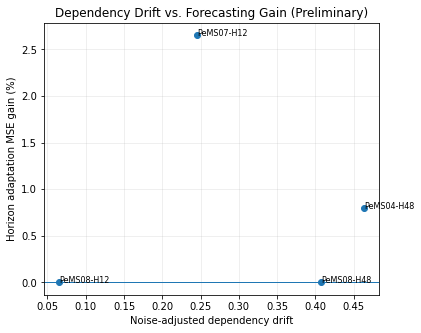

In [19]:

GAIN_CSV_CANDIDATES = [
    Path(
        "./results_two_stage_identity_fallback/"
        "identity_fallback_results.csv"
    ),
    Path(
        "./results_two_stage_identity_fallback/"
        "results_partial.csv"
    ),
]

gain_path = None

for p in GAIN_CSV_CANDIDATES:
    if p.exists():
        gain_path = p
        break

if gain_path is None:

    print(
        "Identity-fallback result CSV not found."
    )

    print(
        "This is not an error. "
        "Run the previous experiment first or "
        "set the CSV path manually later."
    )

else:

    print(
        "Found:",
        gain_path
    )

    gain_df = pd.read_csv(
        gain_path
    )

    required_cols = {
        "dataset",
        "pred_len",
        "mse_improvement_%"
    }

    if not required_cols.issubset(
        gain_df.columns
    ):
        raise ValueError(
            "Gain CSV does not contain "
            f"{required_cols}"
        )

    merged_df = (
        summary_df
        .merge(
            gain_df[
                [
                    "dataset",
                    "pred_len",
                    "mse_improvement_%",
                    "selected_mode"
                ]
            ],
            on=[
                "dataset",
                "pred_len"
            ],
            how="inner"
        )
    )

    print(
        "Merged conditions:",
        len(merged_df)
    )

    display(
        merged_df[
            [
                "dataset",
                "pred_len",
                "selected_mode",
                "endpoint_adjusted_drift_K20",
                "avg_pairwise_adjusted_drift_K20",
                "mse_improvement_%"
            ]
        ].round(
            4
        )
    )

    if len(merged_df) >= 3:

        # Pearson
        pearson_endpoint = (
            merged_df[
                "endpoint_adjusted_drift_K20"
            ]
            .corr(
                merged_df[
                    "mse_improvement_%"
                ],
                method="pearson"
            )
        )

        pearson_avg = (
            merged_df[
                "avg_pairwise_adjusted_drift_K20"
            ]
            .corr(
                merged_df[
                    "mse_improvement_%"
                ],
                method="pearson"
            )
        )

        # Spearman without scipy:
        # rank both variables and calculate Pearson on ranks.
        spearman_endpoint = (
            merged_df[
                "endpoint_adjusted_drift_K20"
            ]
            .rank()
            .corr(
                merged_df[
                    "mse_improvement_%"
                ].rank()
            )
        )

        spearman_avg = (
            merged_df[
                "avg_pairwise_adjusted_drift_K20"
            ]
            .rank()
            .corr(
                merged_df[
                    "mse_improvement_%"
                ].rank()
            )
        )

        print(
            "\nPreliminary drift-gain correlations"
        )

        print(
            "Endpoint drift vs gain:"
        )

        print(
            f"  Pearson = "
            f"{pearson_endpoint:.4f}"
        )

        print(
            f"  Spearman = "
            f"{spearman_endpoint:.4f}"
        )

        print(
            "Average drift vs gain:"
        )

        print(
            f"  Pearson = "
            f"{pearson_avg:.4f}"
        )

        print(
            f"  Spearman = "
            f"{spearman_avg:.4f}"
        )

        plt.figure(
            figsize=(6, 5)
        )

        plt.scatter(
            merged_df[
                "avg_pairwise_adjusted_drift_K20"
            ],
            merged_df[
                "mse_improvement_%"
            ]
        )

        for _, row in merged_df.iterrows():

            plt.annotate(
                f"{row['dataset']}-H{int(row['pred_len'])}",
                (
                    row[
                        "avg_pairwise_adjusted_drift_K20"
                    ],
                    row[
                        "mse_improvement_%"
                    ]
                ),
                fontsize=8
            )

        plt.axhline(
            0,
            linewidth=1
        )

        plt.xlabel(
            "Noise-adjusted dependency drift"
        )

        plt.ylabel(
            "Horizon adaptation MSE gain (%)"
        )

        plt.title(
            "Dependency Drift vs. Forecasting Gain "
            "(Preliminary)"
        )

        plt.grid(
            alpha=0.25
        )

        plt.show()

    merged_df.to_csv(
        OUTPUT_DIR
        /
        "drift_gain_preliminary.csv",
        index=False
    )


# 17. How to interpret the results

This section implements the dependency-drift protocol described in the paper. All source selection and normalization use only the designated training interval.
